In [13]:
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

In [14]:
vars = ['ind', 'men', 'men_pauv', 'men_1ind', 'men_5ind', 'men_prop', 'men_fmp', 'ind_snv', 'men_surf', 'men_coll', 'men_mais',
 'log_av45',  'log_45_70',  'log_70_90', 'log_ap90', 'log_inc', 'log_soc', 'ind_0_3', 'ind_4_5', 'ind_6_10',
 'ind_11_17',
 'ind_18_24',
 'ind_25_39',
 'ind_40_54',
 'ind_55_64',
 'ind_65_79',
 'ind_80p',
 'ind_inc',
 'x', 'y']

In [17]:
pc = gpd.read_parquet('carreaux-200m-met-3035-2021.parquet')
pc['y'] = pc.idcar_200m.str.slice(15,).str.split('E', expand=True).astype(int).loc[:,0]
pc['x'] = pc.idcar_200m.str.slice(15,).str.split('E', expand=True).astype(int).loc[:,1]
j = ((pc.y - pc.y.min())/200).astype(int) 
i = ((pc.x - pc.x.min())/200).astype(int) 

In [16]:
pc['nvm'] = pc.ind_snv / pc.ind

KeyboardInterrupt: 

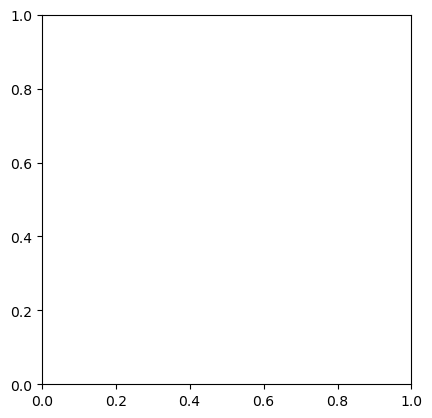

In [11]:
pc.plot('nvm', scheme="quantiles")

In [18]:
hmatrix = np.zeros((max(j)+1, max(i)+1, len(vars))) 

for ii, var in enumerate(vars):
    hmatrix[127-j, i, ii] = pc[var]

In [5]:
hmatrix[:,:,0].sum()

62592659.0

In [13]:
temp = hmatrix[715:(715+4096), 637:(637+4096),:]
temp.shape

(4096, 4046, 30)

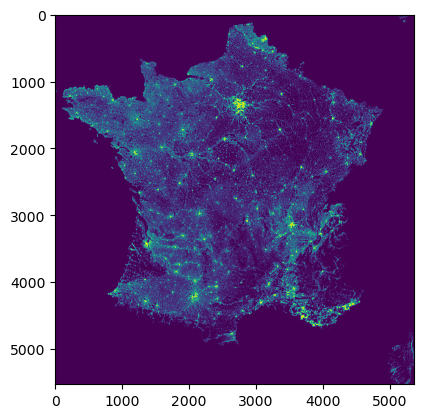

In [82]:
plt.imshow(hmatrix[:,:,0]>0)

In [ ]:
np.save('carreaux-200m-met-3035-2021s.npy', hmatrix[715:(715+4096), 637:(637+4096),:])

In [23]:
temp = pc[vars].sum(axis=0)
for i, t in enumerate(temp):
    print(i, vars[i], t)

0 ind 62592659.0
1 men 28279067.0
2 men_pauv 4251505.900000002
3 men_1ind 10423117.300000003
4 men_5ind 1746324.0
5 men_prop 16728465.399999999
6 men_fmp 3048417.700000001
7 ind_snv 1572535725235.901
8 men_surf 2486389444.0
9 men_coll 12175886.500000002
10 men_mais 16103180.499999996
11 log_av45 7474605.600000002
12 log_45_70 4758636.399999999
13 log_70_90 6791990.7
14 log_ap90 9203696.899999999
15 log_inc 50137.40000000001
16 log_soc 4410799.8999999985
17 ind_0_3 2566143.7000000007
18 ind_4_5 1397226.8000000014
19 ind_6_10 3782372.700000002
20 ind_11_17 5458766.5
21 ind_18_24 4640778.700000002
22 ind_25_39 11147258.3
23 ind_40_54 12341354.699999997
24 ind_55_64 8115167.000000004
25 ind_65_79 9530063.799999997
26 ind_80p 3569546.1000000006
27 ind_inc 43980.70000000003
28 x 8522593471400.0
29 y 6078017818800.0
